In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# DATA PREP

In [2]:
data = pd.read_csv('Unicum_last_flagged.csv',skiprows=[0,1,2],sep='\s+',on_bad_lines='skip')

aliases = {
        '0219+428': '3C66A',
        '0316+41': '3C84',
        '0355+508': 'NRAO150',
        '0851+202': 'OJ287',
        '1226+023': '3C273',
        '1253-055': '3C279',
        '1641+399': '3C345',
        '2200+420': 'BLLAC',
        '2251+158': '3C454.3',
        'Mrk501': 'Mrk501',
        '3c207': '3c207',
        'PKS1222+216': '1221+21',
        'BS0846+513': '0846+513',
        'CTA102': '2230+114'
    }

def replace_aliases(data, aliases):
    data_copy = data.copy()
    for original, alias in aliases.items():
        data_copy['Name'] = data_copy['Name'].replace(original, alias)
    return data_copy

data_with_aliases_replaced = replace_aliases(data, aliases)


print(data['Name'].unique())
len(data_with_aliases_replaced['Name'].unique())

['1221+21' '3C147' 'MRK421' 'NESCI' '3C84' 'MRK501' '0948+0022'
 'S41849+67' '1510-089' 'BS0846+513' 'PKS1346-112' '3C273' '1156+295'
 '1219+285' '1354+195' '1606+105' '0716+714' '1730-130' '1741-038'
 '1611+343' '1633+382' '3C345' '0954+658' '0836+710' '2223-052' '2230+114'
 '3C454.3' '2344+092' 'NRAO150' '0235+164' '0336-019' '0420-014'
 '0528+134' 'DR21' '3C279' '3C66A' '1334-127' '1807+698' 'BLLAC'
 '0440-003' '0736+017' '0735+178' '0827+243' 'OJ287' '0829+046'
 'TXS0536+145' '3C207' '1055+567' '3C380' 'CTA102' '0846+513' 'B20218+35'
 'SgrA' 'PG1553+113' '0323+342' '1227+25' '2007+77' 'J0902+0443'
 'S40444+63' 'TXS0506+056' '1ES1959+650' '1ES2344+514' 'PKS1222+216'
 'PKS1441+25' 'PKSJ1153-1105' '1830-211' 'MHz' 'Mrk501' '3c207' '***']


67

In [3]:
data_NEW = pd.read_csv('new_SRT_data.txt',skiprows=1,sep='\s+',on_bad_lines='skip')
data_NEW['Flux']= (data_NEW['flux_0']+data_NEW['flux_1'])/2
data_NEW['e_Flux']= abs((data_NEW['e_flux_0']+data_NEW['e_flux_1'])/2)
source_u=data_NEW['Name'].unique()
source_u

array(['PKS1222+216', '3C273', '3C279', '1334-127', '1354+195',
       'PKS1441+25', '1510-089', 'PG1553+113', '1606+105', '1830-211',
       '1730-130', '1741-038', '1611+343', '1633+382', '3C345', 'Mrk501',
       '1807+698', 'BLLAC', '1ES1959+650', '2223-052', '2230+114',
       '3C454.3', '3C380', '3C66A', '3C84', '2344+092', '0235+164',
       'NRAO150', '0336-019', '0420-014', '0440-003', 'TXS0506+056',
       '1ES2344+514', '0528+134', '0716+714', '0736+017', '0735+178',
       '0827+243', '0829+046', '3c207', '0836+710', 'OJ287', '0954+658',
       'MRK421', '1156+295', '1219+285'], dtype=object)

In [4]:
def get_source_data(data, source):
    source_data = data[data['Name'] == source]
    return source_data

# Plotting individual sources

In [8]:
source = 'NRAO150'
source_data = get_source_data(data, source)

print(source_data)

         Name  HHMMSS         #MJD     Freq     Elev     Flux  e_Flux
112   NRAO150  171742  55916.72266   5125.0  52.0099   6.4749  0.0749
203   NRAO150  182640  55916.77344   8305.0  62.7703   8.1215  0.1957
232   NRAO150  145926  55943.62891   5125.0  47.1325   6.9803  0.0762
253   NRAO150  155715  55973.66797   5125.0  74.4423   7.7993  0.1274
284   NRAO150  133628  56002.57031   5125.0  70.0840   7.5881  0.1257
...       ...     ...          ...      ...      ...      ...     ...
9403  NRAO150  094949  60088.41125  24100.0  75.7198  11.2260  0.1356
9490  NRAO150  072552  60116.31128  24100.0  70.5360  10.6617  0.1391
9517  NRAO150  045349  60152.20569  22664.0  68.8860  10.2849  0.1409
9554  NRAO150  030317  60179.12894  24100.0  68.1971  11.1544  0.1446
9599  NRAO150  011348  60206.05291  24100.0  67.6741  11.1393  0.1517

[247 rows x 7 columns]


In [9]:
source = 'NRAO150'
source_data_new = get_source_data(data_NEW, source)
print(source_data_new)

        Name  HHMMSS         #MJD     Freq     Elev     Amp_0     Amp_1  \
27   NRAO150  140757  60713.59078   4825.0  46.8512  119.8980  104.2705   
64   NRAO150  125157  60735.53800   4825.0  48.4918  112.4934   97.5579   
118  NRAO150  150349  60713.62931  24600.0  55.8509   39.5925   42.5052   
149  NRAO150  134829  60735.57699  24600.0  57.6098   36.2018   39.6477   
214  NRAO150   95741  60782.41698   4825.0  50.1412   71.4409   78.9675   
225  NRAO150  112501  60782.47736  24600.0  64.0597   23.5541   24.8740   

     e_Amp_0  e_Amp_1   flux_0   flux_1  e_flux_0  e_flux_1      Flux   e_Flux  
27    0.1889   0.1636   8.3924   7.3417    0.0909    0.0805   7.86705  0.08570  
64    0.1764   0.1488   9.2765   7.9468    0.0741    0.0632   8.61165  0.06865  
118   0.1017   0.0829  12.2118  12.3410    0.1142    0.1057  12.27640  0.10995  
149   0.1210   0.1441  12.5136  12.4871    0.0949    0.0913  12.50035  0.09310  
214   0.2424   0.2452   8.5962   8.6132    0.1350    0.1315   8.60470

# PLOT

C:\Users\Rupal Giri\AppData\Local\Temp\ipykernel_16452\1340728384.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_data['Freq'] = pd.to_numeric(source_data['Freq'], errors='coerce')
C:\Users\Rupal Giri\AppData\Local\Temp\ipykernel_16452\1340728384.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_data['#MJD'] = pd.to_numeric(source_data['#MJD'], errors='coerce')
C:\Users\Rupal Giri\AppData\Local\Temp\ipykernel_16452\1340728384.py:4: SettingWithCopyWarning: 
A value is trying to be set on 

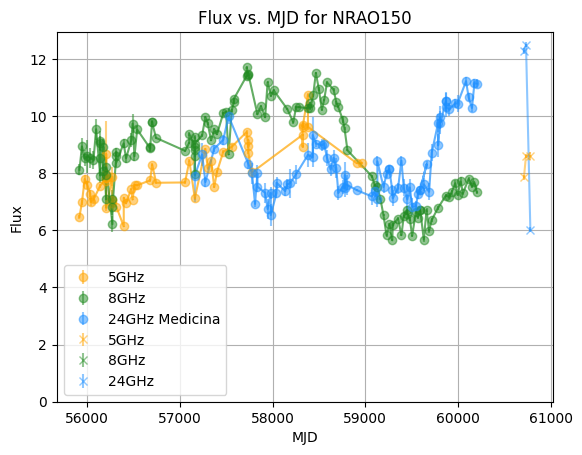

In [10]:

# Ensure 'Freq', '#MJD', 'Flux', and 'e_Flux' columns are numeric
source_data['Freq'] = pd.to_numeric(source_data['Freq'], errors='coerce')
source_data['#MJD'] = pd.to_numeric(source_data['#MJD'], errors='coerce')
source_data['Flux'] = pd.to_numeric(source_data['Flux'], errors='coerce')
source_data['e_Flux'] = pd.to_numeric(source_data['e_Flux'], errors='coerce')
source_data_new['Freq'] = pd.to_numeric(source_data_new['Freq'], errors='coerce')
source_data_new['#MJD'] = pd.to_numeric(source_data_new['#MJD'], errors='coerce')
source_data_new['Flux'] = pd.to_numeric(source_data_new['Flux'], errors='coerce')
source_data_new['e_Flux'] = pd.to_numeric(source_data_new['e_Flux'], errors='coerce')


f_data_5 =  source_data[(source_data['Freq'] >= 4000) & (source_data['Freq'] <= 7000)]
f_data_8 =  source_data[(source_data['Freq'] >= 7000) & (source_data['Freq'] <= 9000)]
f_data_20 =  source_data[(source_data['Freq'] >= 15000) & (source_data['Freq'] <= 30000)]
f_data_5_new =  source_data_new[(source_data_new['Freq'] >= 4000) & (source_data_new['Freq'] <= 7000)]
f_data_8_new =  source_data_new[(source_data_new['Freq'] >= 7000) & (source_data_new['Freq'] <= 9000)]
f_data_20_new =  source_data_new[(source_data_new['Freq'] >= 15000) & (source_data_new['Freq'] <= 30000)]




#plt.figure(figsize=(7,4))
plt.errorbar((f_data_5['#MJD']), f_data_5['Flux'], yerr=f_data_5['e_Flux'], fmt='o', label='5GHz',color='orange',alpha=0.5,markersize=6)
plt.errorbar((f_data_8['#MJD']), f_data_8['Flux'], yerr=f_data_8['e_Flux'], fmt='o', label='8GHz',color='forestgreen',alpha=0.5,markersize=6)
plt.errorbar((f_data_20['#MJD']), f_data_20['Flux'], yerr=f_data_20['e_Flux'], fmt='o', label='24GHz Medicina',color='dodgerblue',alpha=0.5,markersize=6)
plt.plot((f_data_5['#MJD']), f_data_5['Flux'],color='orange',alpha=0.7)
plt.plot((f_data_8['#MJD']), f_data_8['Flux'],color='forestgreen',alpha=0.7)
plt.plot((f_data_20['#MJD']), f_data_20['Flux'],color='dodgerblue',alpha=0.7)

plt.errorbar((f_data_5_new['#MJD']), f_data_5_new['Flux'], yerr=f_data_5_new['e_Flux'], fmt='x', label='5GHz',color='orange',alpha=0.5,markersize=6)
plt.errorbar((f_data_8_new['#MJD']), f_data_8_new['Flux'], yerr=f_data_8_new['e_Flux'], fmt='x', label='8GHz',color='forestgreen',alpha=0.5,markersize=6)
plt.errorbar((f_data_20_new['#MJD']), f_data_20_new['Flux'], yerr=f_data_20_new['e_Flux'], fmt='x', label='24GHz',color='dodgerblue',alpha=0.5,markersize=6)
plt.plot((f_data_5_new['#MJD']), f_data_5_new['Flux'],color='orange',alpha=0.5,markersize=6)
plt.plot((f_data_8_new['#MJD']), f_data_8_new['Flux'],color='forestgreen',alpha=0.5,markersize=6)
plt.plot((f_data_20_new['#MJD']), f_data_20_new['Flux'],color='dodgerblue',alpha=0.5,markersize=6)    


plt.grid(True)

plt.grid(True)
plt.xlabel('MJD')
plt.ylabel('Flux')
plt.title('Flux vs. MJD for NRAO150')
plt.ylim(0,)
plt.legend()
plt.savefig('images/new_data/flux_vs_mjd_NRAO150.png', dpi=300)

# Analysis

source_u

(array([ 9.,  9.,  9.,  9.,  8.,  9.,  9.,  9.,  9.,  8.,  9.,  9.,  9.,
         9.,  8.,  9.,  9.,  9.,  9.,  8.,  9.,  9.,  9.,  9., 11.,  8.,
         9.,  9.,  9.,  9.]),
 array([  0. ,   8.8,  17.6,  26.4,  35.2,  44. ,  52.8,  61.6,  70.4,
         79.2,  88. ,  96.8, 105.6, 114.4, 123.2, 132. , 140.8, 149.6,
        158.4, 167.2, 176. , 184.8, 193.6, 202.4, 211.2, 220. , 228.8,
        237.6, 246.4, 255.2, 264. ]),
 <BarContainer object of 30 artists>)

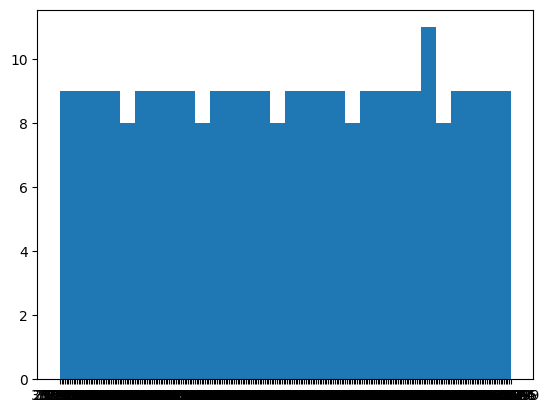

In [24]:
dat_1 = get_source_data(data,source_u[1])
dat_1
plt.hist(dat_1['Flux'],bins=30)